In [1]:
from pyTNG import utils
from pyTNG import data_interface as _data_interface
import os
import pandas as pd
import numpy as np
import illustris_python as il
from pyTNG.spectra import StarSpectrumFactory
from pyTNG import spectra
import matplotlib.pyplot as plt
import time
import astropy.units as u
import scipy.integrate as integ
import pyTNG.utils as utils
from pyTNG.cosmology import TNGcosmo

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [3]:
h = TNGcosmo.h

In [4]:
%load_ext autoreload
%autoreload 2

In [34]:
from df_level0 import *
from add_column_dens import *

In [10]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/df_with_volumes.pickle'
df = pd.read_pickle(df_path)

In [118]:
sim, sim_path = get_sim()
z = sim.snap_cat[13].header['Redshift']
get_column_height_dens(df, z)

In [99]:
def get_sub_dataset_df(sim, snap_num):
    dataset = next(sim.group_cat[snap_num].chunk_generator('subhalo'))
    keys_needed = ['SubhaloHalfmassRadType']
    sub_dict = {key: dataset[key] for key in keys_needed}
    dataset_df = utils.dfFromArrDict(sub_dict)
    return dataset_df

In [101]:
sub_dataset = get_sub_dataset_df(sim, snap_num=13)

In [120]:
def keepWindParticles(starAndWindParts):
    try:
        # TNG wiki says >= 0 for stars, but that doesn't make sense so use > 0
        # here
        idces = starAndWindParts['GFM_StellarFormationTime'] < 0
        utils._keepPartsByIdx(starAndWindParts, idces)
    except KeyError as e:
        if str(e) == 'GFM_StellarFormationTime' and starAndWindParts['count'] == 0:
            pass
        else:
            raise
    return

In [103]:
len(sub_dataset)

8861273

In [155]:
mass_to_g = (1*u.Msun).to(u.kg).value*1e10/h
filt = df[('SubhaloMassInRadType',0)]*mass_to_g/df[('masses', 0)]>2
df[filt][('SubhaloMassInRadType',0)]*mass_to_g/(df[filt][('masses', 0)]+wind_mass)

0          1.000070
642        0.594932
2668       0.440438
5531       0.252265
6191       0.176927
9740       0.262029
61145      0.006864
62189      0.033468
64968      0.010408
142686     0.002147
171432     0.036548
172486     0.001738
180241     0.002315
256485     0.000661
307913     0.007335
454633     0.001314
480679     0.000628
499091     0.000021
541302     0.000579
567321     0.000863
586467     0.000525
612192     0.001304
729970     0.001378
874235     0.002295
1062039    0.000259
dtype: float64

In [151]:
stars = il.snapshot.loadSubhalo(sim_path, 13, 0, 'stars')

In [152]:
keepWindParticles(stars)

In [153]:
get_particle_dist(stars, df, 0) 

In [154]:
wind_in_rad = stars['rel_dist'] < 1
wind_mass = np.sum(stars['Masses'][wind_in_rad])*mass_to_g

In [143]:
keepWindParticles(stars)

In [131]:
len(stars_test)

20

In [140]:
stars = il.snapshot.loadSubhalo(sim_path, 13, 642, 'stars')

In [126]:
stars['GFM_StellarFormationTime']

array([-0.02254158, -0.01020283, -0.00519054, ..., -0.02119155,
       -0.00024766, -0.01794857], dtype=float32)

In [123]:
len(stars)

20

In [124]:
keepWindParticles(stars)

In [125]:
len(stars)

20

In [106]:
df_merged = df.merge(sub_dataset, left_index=True, right_index=True, log=True)

In [111]:
def plot_histogram(df, prop, labels=None, bins=100):
    labelsize = 55
    x_tick_major_size = 16
    x_tick_major_width = 4
    x_tick_minor_size = 8
    x_tick_minor_width = 3
    fig_width = 25
    fig_height = 15
    axes_width = 3
    tick_labelsize = 35
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
    
    if prop == 'column_dens':
        x_label = r'$\log(\rho)[\log(\mathrm{gcm}^{-3})]$'
        y_label = r'p.d.f.($\log(\rho)$)'
        labels = {'x':x_label, 'y':y_label}
    elif prop == 'column_height':
        x_label = '$\log(h)[\log(\mathrm{cm})]$'
        y_label = r'p.d.f.($\log(h)$)'
        labels = {'x':x_label, 'y':y_label}
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]
    ax.hist(input_val, bins=100, density=True)
    ax.set_xlabel(labels['x'], size=labelsize)
    ax.set_ylabel(labels['y'], size=labelsize)
    plt.show();
    return

In [109]:
df_merged.columns

MultiIndex([(       'SubhaloGasMetallicity', 0),
            ('SubhaloGasMetallicityHalfRad', 0),
            (      'SubhaloHalfmassRadType', 4),
            (        'SubhaloMassInHalfRad', 0),
            (    'SubhaloMassInHalfRadType', 4),
            (            'SubhaloMassInRad', 0),
            (        'SubhaloMassInRadType', 0),
            (        'SubhaloMassInRadType', 4),
            (         'SubhaloSFRinHalfRad', 0),
            (             'SubhaloSFRinRad', 0),
            (                  'SubhaloPos', 0),
            (                  'SubhaloPos', 1),
            (                  'SubhaloPos', 2),
            (                      'masses', 0),
            (                     'volumes', 0),
            (               'column_height', 0),
            (                 'column_dens', 0)],
           )

In [112]:
x_label = '$f_g$'
y_label = 'pdf($f_g$)'
labels = {'x': x_label, 'y': y_label}

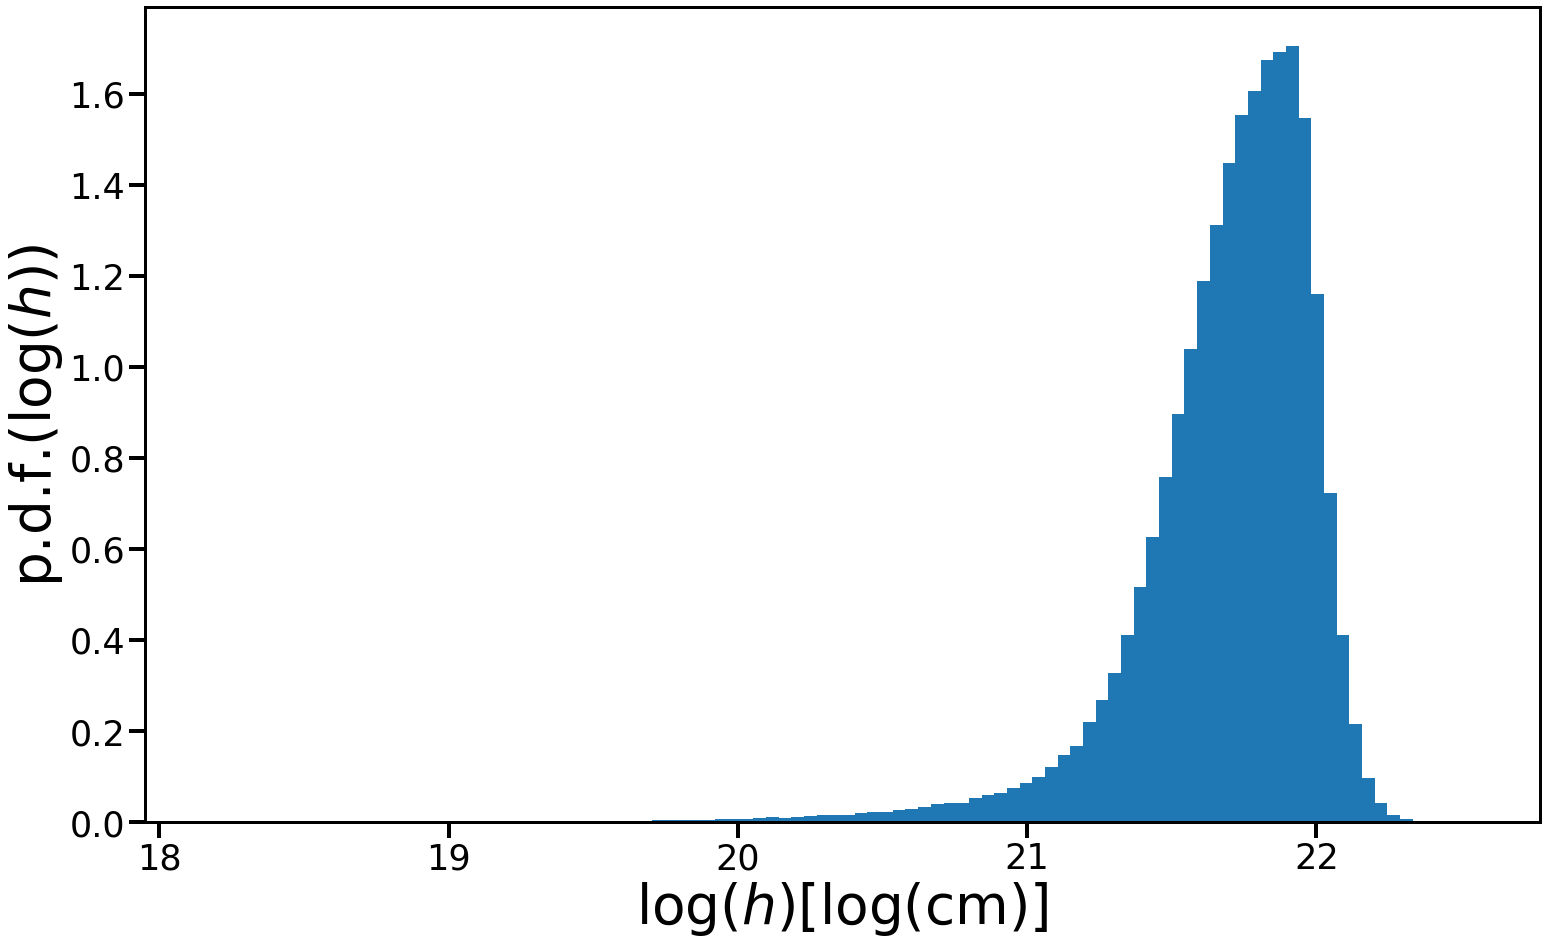

In [97]:
plot_histogram(df=df_merged, prop=('')